Saving fitdata.txt to fitdata.txt
c estimated =  -0.02005478877387395


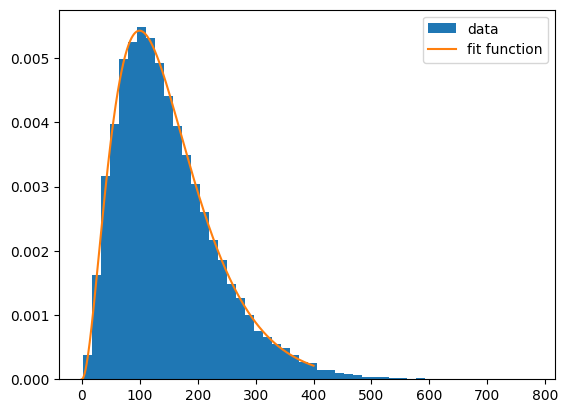

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
uploaded = files.upload()### first fit data
points = np.genfromtxt('fitdata.txt')
N = points.size
average = np.sum(points)/N
c_estimated = -3/average
print("c estimated = ",c_estimated)
min=0
max=400

def func_fixed(xs):
    return -c_estimated*c_estimated*c_estimated/(2)*xs*xs*np.exp(c_estimated*xs)


plt.hist(points,bins = 50, density = True,label="data")
plt.plot(np.linspace(min,max,1000), np.frompyfunc(func_fixed, 1, 1)(np.linspace(min,max,1000)),label="fit function")
plt.legend()
plt.show()



Saving fitdata3.txt to fitdata3 (1).txt
Estimated a and b =  0.0010971553356344125 1.076910821975628


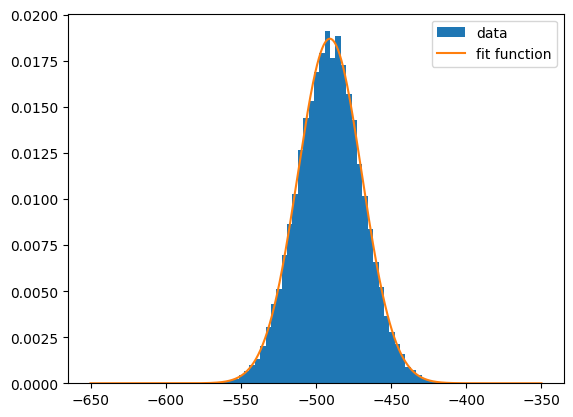

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

def func_fixed(xs):
    k = np.sqrt(np.pi/a)*np.exp(b*b/(4*a))
    return (1./k)*np.exp(-(a*xs*xs + b*xs))

uploaded = files.upload()### first fit data
points = np.genfromtxt('fitdata3.txt')

min=-650
max=-350

N = points.size
avgx = np.sum(points)/N
avgx2 = np.sum(points*points)/N
a = 1./(2*(avgx2 - avgx*avgx))
b = -avgx/(avgx2 - avgx*avgx)
print("Estimated a and b = ",a,b)

plt.hist(points,bins = 50, density = True,label="data")
plt.plot(np.linspace(min,max,1000), np.frompyfunc(func_fixed, 1, 1)(np.linspace(min,max,1000)),label="fit function")
plt.legend()
plt.show()



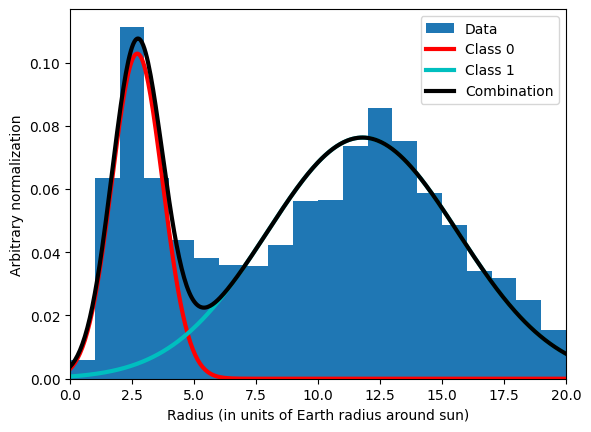

r =  5.8181633 and fit0 =  0.001009188284179668 and fit1 =  0.022921942280485406 and max ratio =  22.713246516845775
r =  11.2154 and fit0 =  9.515048723355067e-17 and fit1 =  0.07541666710033923 and max ratio =  792604108429061.5
r =  11.3113 and fit0 =  4.340187357377608e-17 and fit1 =  0.07567471781344243 and max ratio =  1743581822218061.5
r =  6.54449 and fit0 =  9.036658022725918e-05 and fit1 =  0.030163839429374065 and max ratio =  333.79418977144286
r =  8.6950898 and fit0 =  3.693757152507361e-09 and fit1 =  0.055210289016201584 and max ratio =  14946919.01407873
r =  14.7752 and fit0 =  5.780635087701048e-32 and fit1 =  0.056512281067575075 and max ratio =  9.776137087049712e+29
r =  3.19621 and fit0 =  0.09179984093680041 and fit1 =  0.006329876852915632 and max ratio =  14.502626681357329
r =  13.1874503 and fit0 =  1.5828703861118204e-24 and fit1 =  0.07142438260381855 and max ratio =  4.512332988885221e+22
r =  5.9115908 and fit0 =  0.0007611299507210051 and fit1 =  0.023

In [14]:
# Exercise 11.4
from math import sqrt,pi
from numpy import empty, zeros, array, loadtxt, linspace
from numpy import copy, exp, genfromtxt
import matplotlib.pyplot as plt
from google.colab import files

k = 2 ### number of groups
xmin = 0.0
xmax = 20.0
npoints = 400
xpoints = linspace(xmin,xmax,npoints+1)
target = 1e-6 ### for everything, could have separate ones
Nloopmax = 100

# Gaussian
def gaussian(x,mu,sigma):
  return exp(-(x-mu)**2/(2*sigma**2))/(sqrt(2*pi)*sigma)

# Read the data
uploaded = files.upload() ### To upload!
data = genfromtxt('exoplanets.txt')
x = data[:,4]
N = len(x)

# Choose initial values for the parameters, these do not have to be perfect
mu = array([1.0,3.0],float)
sigma = array([1.0,1.0],float)
gamma = array([0.5,0.5],float)

# Main loop
q = empty([N,k],float)
for j in range(Nloopmax): ### need to make sure we stop before then, we'll check at the end
    # Calculate the qiz's
    for i in range(N):
      for z in range(k):
        q[i,z] = gamma[z]*gaussian(x[i],mu[z],sigma[z])
      norm = sum(q[i])
      q[i] /= norm

    # Calculate updated values for the parameters, we can use the analytic form here
    oldmu = copy(mu)
    for z in range(k):
      norm = sum(q[:,z])
      mu[z] = sum(q[:,z]*x)/norm
      sigma[z] = sqrt(sum(q[:,z]*(x-mu[z])**2)/norm)
      gamma[z] = norm/N

    # Check for convergence
    delta = max(abs(mu-oldmu))
    if delta < target:
      break

    if (j == Nloopmax - 1):
      print("WARNING! Made it up to the max Nloop and did not converge")

# Make the plot
plt.hist(x,bins=20,range=[xmin,xmax],density=True, label="Data")
fitsum = zeros(npoints+1,float)
colors = ["r","c"]
for z in range(k):
  fit = gamma[z]*exp(-(xpoints-mu[z])**2 / (2*sigma[z]**2))/sqrt(2*pi*sigma[z]**2)
  fitsum += fit
  plt.plot(xpoints,fit,colors[z], linewidth=3, label=f"Class {z}")
plt.plot(xpoints, fitsum, "k", linewidth=3, label="Combination")
plt.legend()
plt.xlabel("Radius (in units of Earth radius around sun)")
plt.ylabel("Arbitrary normalization")
plt.xlim(xmin,xmax)
plt.show()

Ntocheck = 20
for i in range(Ntocheck):
  r = x[i]
  fit0 = gamma[0]*exp(-(r-mu[0])**2 / (2*sigma[0]**2))/sqrt(2*pi*sigma[0]**2)
  fit1 = gamma[1]*exp(-(r-mu[1])**2 / (2*sigma[1]**2))/sqrt(2*pi*sigma[1]**2)
  print("r = ",r,"and fit0 = ",fit0,"and fit1 = ",fit1, "and max ratio = ", max(fit0/fit1,fit1/fit0))
